<a href="https://colab.research.google.com/github/yakubavm/monitoring_of_production_processes/blob/LR_5/LR_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Налаштування стилю візуалізації
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.figsize'] = (10, 6)

class ClosedQueuingSystem:
    """
    Математичне ядро для розрахунку сталих процесів у замкнутих СМО (M/M/1//m).
    Генерує матрицю рівнянь балансу та розв'язує СЛАР для пошуку ймовірностей станів.
    """

    @staticmethod
    def solve_balance_equations(m: int, lmbda: float, mu: float) -> np.ndarray:
        """
        Формує матрицю коефіцієнтів A та вектор B для системи рівнянь Колмогорова.
        Розв'язує систему A * P = B.
        """
        size = m + 1
        A = np.zeros((size, size))
        B = np.zeros(size)

        # Генерація рівнянь балансу інтенсивностей для кожного стану k
        for k in range(size):
            if k == 0:
                A[k, 0] = -m * lmbda
                A[k, 1] = mu
            elif k == m:
                A[k, m-1] = lmbda
                A[k, m] = -mu
            else:
                A[k, k-1] = (m - k + 1) * lmbda
                A[k, k] = -((m - k) * lmbda + mu)
                A[k, k+1] = mu

        # Заміна останнього рівняння на умову нормування (сума всіх ймовірностей = 1)
        A[-1, :] = 1.0
        B[-1] = 1.0

        # Аналітичне розв'язання СЛАР (аналог блоку Given...Find у Mathcad)
        probabilities = np.linalg.solve(A, B)
        return probabilities

In [3]:
# Завдання 1: Визначення вхідних параметрів СМО та розрахунок інтенсивностей
print("-" * 75)
print("БЛОК 1: Ініціалізація параметрів замкнутої СМО (Варіант 15)")
print("-" * 75)

# Вихідні дані
m_trucks = 5               # Кількість автосамоскидів
capacity_truck = 1.0       # Ємність самоскида, т
capacity_bucket = 6.0      # Ємність ковша, т
t_cycle_excavator = 17.0   # Час робочого циклу екскаватора, с
t_turnaround_truck = 1200.0 # Час обернення самоскида (20 хв * 60 с)

# Розрахунок часу обслуговування.
# Оскільки ємність ковша (6т) більша за ємність самоскида (1т),
# завантаження відбувається за 1 робочий цикл.
t_service = t_cycle_excavator

# Обчислення інтенсивностей потоків (в одиницях 1/с)
# λ (лямбда) - інтенсивність надходження одного самоскида
lmbda = 1.0 / t_turnaround_truck
# μ (мю) - інтенсивність обслуговування (завантаження)
mu = 1.0 / t_service

print(f"Кількість джерел вимог (самоскидів), m: {m_trucks}")
print(f"Середній час обслуговування (t_обсл): {t_service} с")
print(f"Середній час обернення (t_оберн): {t_turnaround_truck} с")
print(f"Інтенсивність вхідного потоку від 1 машини (λ): {lmbda:.6f} с^-1")
print(f"Інтенсивність обслуговування (μ): {mu:.6f} с^-1")
print(f"Відносне навантаження (ρ = λ/μ): {lmbda/mu:.6f}")

---------------------------------------------------------------------------
БЛОК 1: Ініціалізація параметрів замкнутої СМО (Варіант 15)
---------------------------------------------------------------------------
Кількість джерел вимог (самоскидів), m: 5
Середній час обслуговування (t_обсл): 17.0 с
Середній час обернення (t_оберн): 1200.0 с
Інтенсивність вхідного потоку від 1 машини (λ): 0.000833 с^-1
Інтенсивність обслуговування (μ): 0.058824 с^-1
Відносне навантаження (ρ = λ/μ): 0.014167


In [4]:
# Завдання 2: Знаходження ймовірностей станів СМО
print("-" * 75)
print("БЛОК 2: Розв'язання системи рівнянь балансу")
print("-" * 75)

# Виклик математичного ядра для розрахунку
P = ClosedQueuingSystem.solve_balance_equations(m_trucks, lmbda, mu)

# Формування звіту у вигляді DataFrame
states_labels = [f"P{k} (В системі {k} машин)" for k in range(m_trucks + 1)]
df_probs = pd.DataFrame({
    "Стан": states_labels,
    "Ймовірність": P,
    "Ймовірність (%)": P * 100
})

display(df_probs.round(6))

print("\nПеревірка нормування (Сума P_i):", np.sum(P))
if np.isclose(np.sum(P), 1.0):
    print("Рішення СЛАР математично коректне.")

---------------------------------------------------------------------------
БЛОК 2: Розв'язання системи рівнянь балансу
---------------------------------------------------------------------------


,Стан,Ймовірність,Ймовірність (%)
0,P0 (В системі 0 машин),0.930213,93.021290
1,P1 (В системі 1 машин),0.065890,6.589008
2,P2 (В системі 2 машин),0.003734,0.373377
3,P3 (В системі 3 машин),0.000159,0.015869
4,P4 (В системі 4 машин),0.000004,0.000450
5,P5 (В системі 5 машин),0.000000,0.000006



Перевірка нормування (Сума P_i): 1.0
Рішення СЛАР математично коректне.


In [5]:
# Завдання 3: Розрахунок продуктивності, довжини черги та коефіцієнтів простою
print("-" * 75)
print("БЛОК 3: Аналіз показників ефективності комплексу")
print("-" * 75)

# 1. Ймовірність простою екскаватора (в системі 0 машин)
p_idle_excavator = P[0]

# 2. Коефіцієнт завантаження екскаватора
k_utilization = 1.0 - p_idle_excavator

# 3. Середня кількість машин у черзі (Lq)
# Черга утворюється, якщо в системі більше 1 машини (1 завантажується, інші чекають)
L_q = sum((k - 1) * P[k] for k in range(2, m_trucks + 1))

# 4. Середня кількість машин у системі (Ls)
L_s = sum(k * P[k] for k in range(1, m_trucks + 1))

# 5. Продуктивність екскаватора (машин на годину)
# Дорівнює інтенсивності обслуговування помноженій на частку часу роботи
productivity_trucks_per_hour = k_utilization * mu * 3600

# 6. Продуктивність у тоннах на годину
productivity_tons_per_hour = productivity_trucks_per_hour * capacity_truck

print(f"Ймовірність простою екскаватора (P0): {p_idle_excavator:.4f} ({p_idle_excavator*100:.2f}%)")
print(f"Коефіцієнт використання екскаватора (η): {k_utilization:.4f} ({k_utilization*100:.2f}%)")
print(f"Середня кількість самоскидів у черзі (L_q): {L_q:.4f} од.")
print(f"Середня кількість самоскидів у системі (L_s): {L_s:.4f} од.")
print(f"Фактична продуктивність комплексу: {productivity_trucks_per_hour:.2f} рейсів/год")
print(f"Обсяг перевезеної породи: {productivity_tons_per_hour:.2f} т/год\n")

print("Аналітичний висновок:")
if k_utilization < 0.5:
    print("Екскаватор суттєво недовантажений. Доцільно збільшити кількість самоскидів (m).")
elif L_q > 2.0:
    print("Висока довжина черги. Самоскиди простоюють. Доцільно виділити додатковий екскаватор.")
else:
    print("Система збалансована. Кількість самоскидів є оптимальною для даного екскаватора.")

---------------------------------------------------------------------------
БЛОК 3: Аналіз показників ефективності комплексу
---------------------------------------------------------------------------
Ймовірність простою екскаватора (P0): 0.9302 (93.02%)
Коефіцієнт використання екскаватора (η): 0.0698 (6.98%)
Середня кількість самоскидів у черзі (L_q): 0.0041 од.
Середня кількість самоскидів у системі (L_s): 0.0739 од.
Фактична продуктивність комплексу: 14.78 рейсів/год
Обсяг перевезеної породи: 14.78 т/год

Аналітичний висновок:
Екскаватор суттєво недовантажений. Доцільно збільшити кількість самоскидів (m).


---------------------------------------------------------------------------
БЛОК 4: Візуалізація розподілу ймовірностей
---------------------------------------------------------------------------


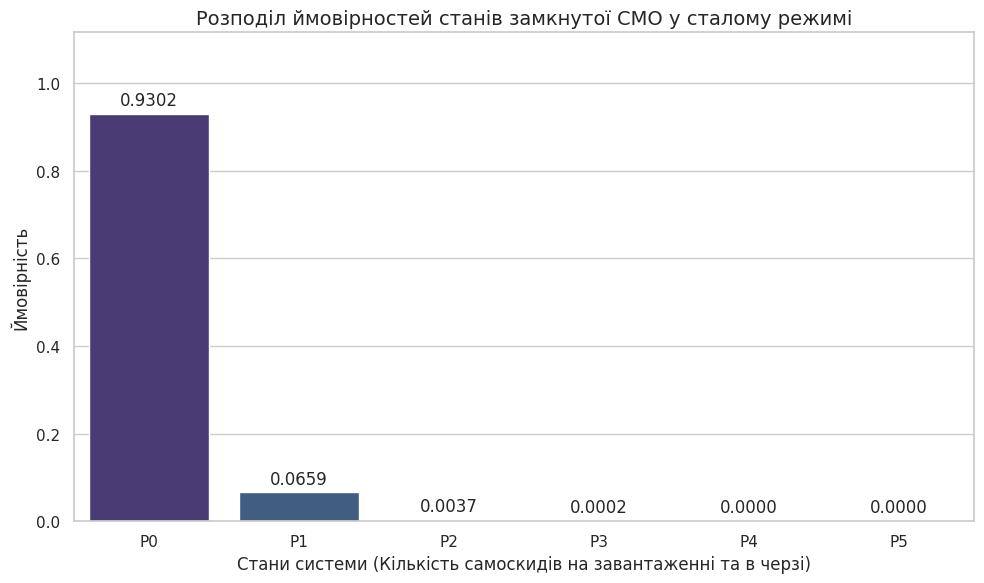

In [8]:
# Завдання 4: Графічне представлення результатів
print("-" * 75)
print("БЛОК 4: Візуалізація розподілу ймовірностей")
print("-" * 75)

plt.figure(figsize=(10, 6))

# Формування масиву підписів для осі X
x_labels = [f"P{k}" for k in range(m_trucks + 1)]

# Побудова графіка з дотриманням нових стандартів Seaborn (додано hue та legend=False)
ax = sns.barplot(x=x_labels, y=P, hue=x_labels, palette="viridis", legend=False)

plt.title("Розподіл ймовірностей станів замкнутої СМО у сталому режимі", fontsize=14)
plt.xlabel("Стани системи (Кількість самоскидів на завантаженні та в черзі)", fontsize=12)
plt.ylabel("Ймовірність", fontsize=12)

# Автоматичне додавання числових значень над стовпцями гістограми
for p in ax.patches:
    ax.annotate(f"{p.get_height():.4f}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.ylim(0, max(P) * 1.2)
plt.tight_layout()
plt.show()